In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.shape

(1338, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.index

RangeIndex(start=0, stop=1338, step=1)

In [7]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [8]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [10]:
df[['age', 'bmi']]

,age,bmi
0,19,27.900
1,18,33.770
2,28,33.000
3,33,22.705
4,32,28.880
...,...,...
1333,50,30.970
1334,18,31.920
1335,18,36.850
1336,21,25.800


In [11]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [12]:
df.groupby('region')['charges'].sum()

region
northeast    4.343669e+06
northwest    4.035712e+06
southeast    5.363690e+06
southwest    4.012755e+06
Name: charges, dtype: float64

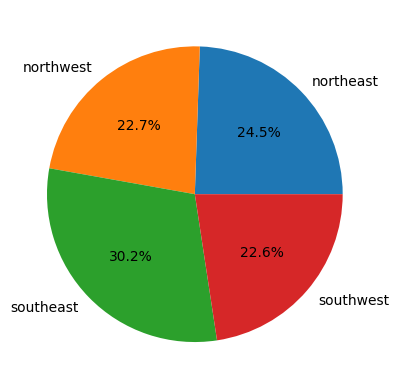

In [13]:
insurance_charges = df.groupby('region')['charges'].sum()
sizes = insurance_charges.index
plt.pie(insurance_charges, labels=sizes, autopct='%1.1f%%')
plt.show()

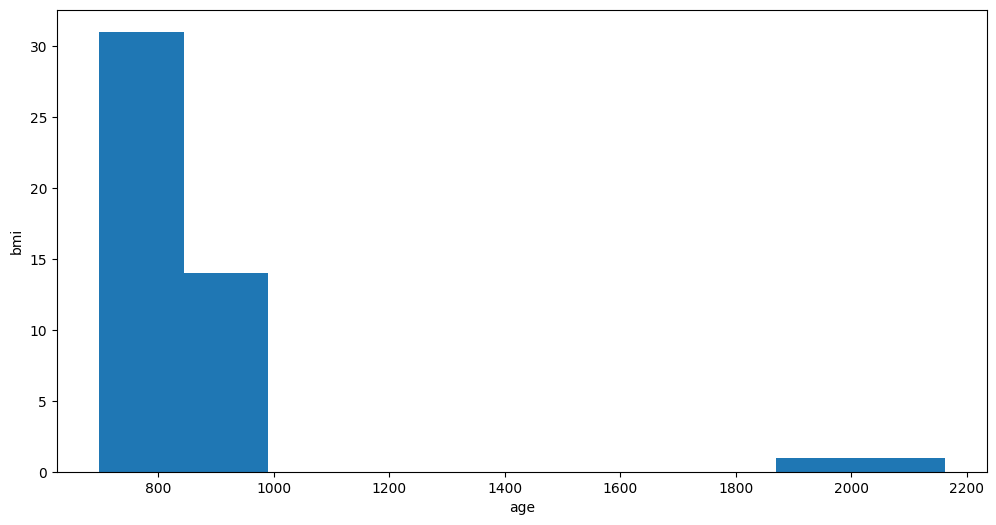

In [14]:
bmi_values = df.groupby('age')['bmi'].sum()
bmi_values.plot(kind='hist', figsize=(12,6))
plt.xlabel('age')
plt.ylabel('bmi')
plt.show()

<Axes: xlabel='age', ylabel='bmi'>

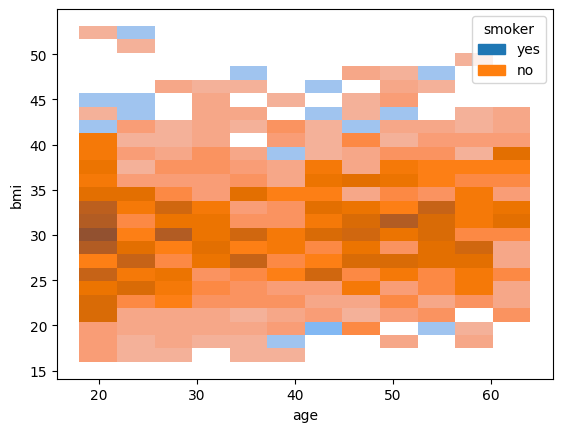

In [15]:
sns.histplot(x='age', y='bmi', hue='smoker', data=df)

<Axes: xlabel='bmi', ylabel='Count'>

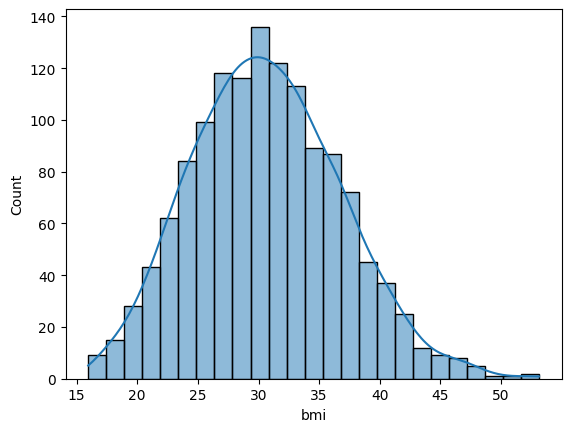

In [16]:
sns.histplot(x='bmi', data=df, kde=True)

<Axes: xlabel='age', ylabel='bmi'>

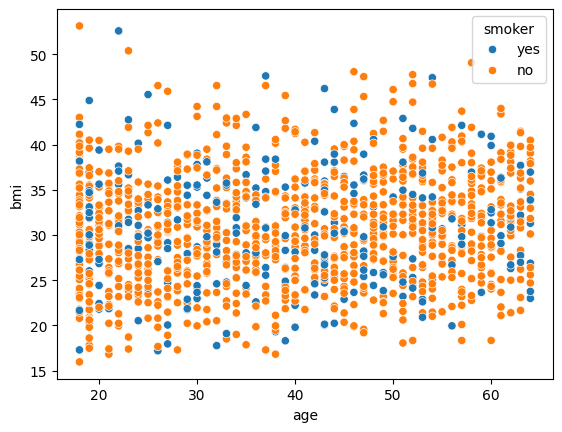

In [17]:
sns.scatterplot(x='age', y='bmi', hue='smoker', data=df)

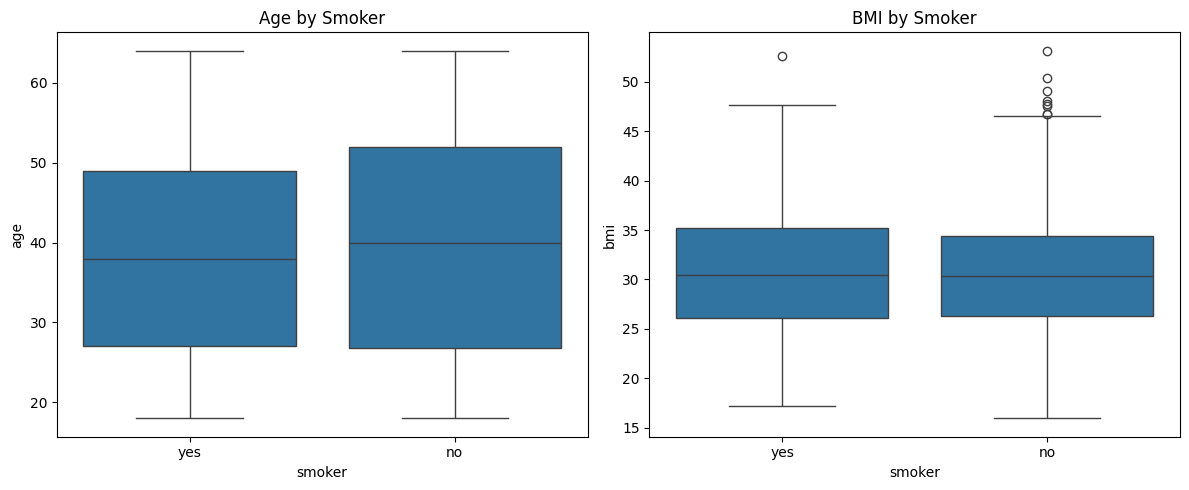

In [18]:
# summary statistics
df.groupby('smoker')[['age', 'bmi']].describe()

# compare distributions
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x='smoker', y='age', data=df)
plt.title('Age by Smoker')

plt.subplot(1,2,2)
sns.boxplot(x='smoker', y='bmi', data=df)
plt.title('BMI by Smoker')

plt.tight_layout()
plt.show()

In [19]:
df.groupby('smoker')[['age', 'bmi']].mean()
df.groupby('smoker')[['age', 'bmi']].median()

,age,bmi
smoker,,
no,40.0,30.3525
yes,38.0,30.4475


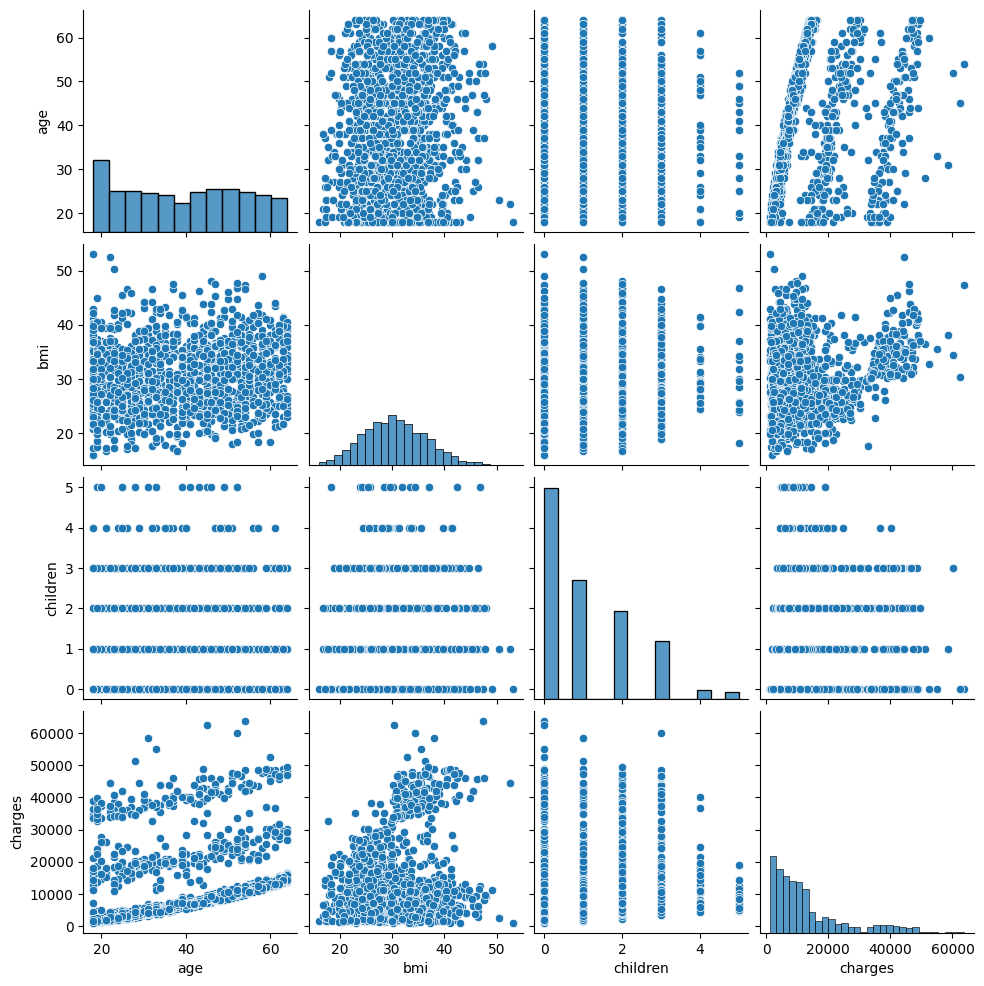

In [20]:
sns.pairplot(df)

In [21]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<Axes: xlabel='smoker', ylabel='sex'>

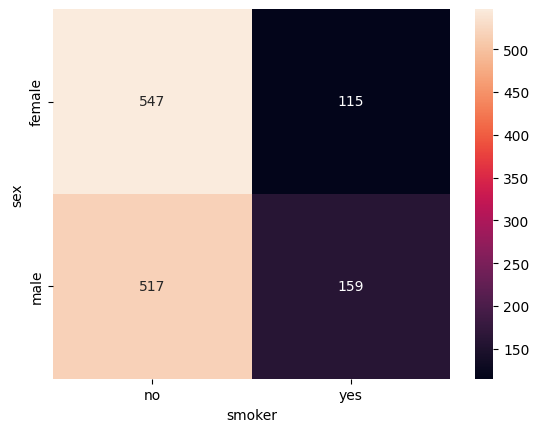

In [30]:
ct = pd.crosstab(df['sex'], df['smoker'])
sns.heatmap(ct, annot=True, fmt='d')

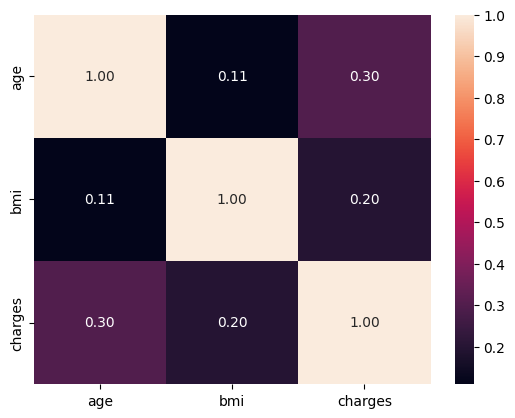

In [28]:
# Compare specific numerical columns
df_numeric = df[['age', 'bmi', 'charges']]
correlation_matrix = df_numeric.corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cbar=True)
plt.show()

<Axes: xlabel='age', ylabel='charges'>

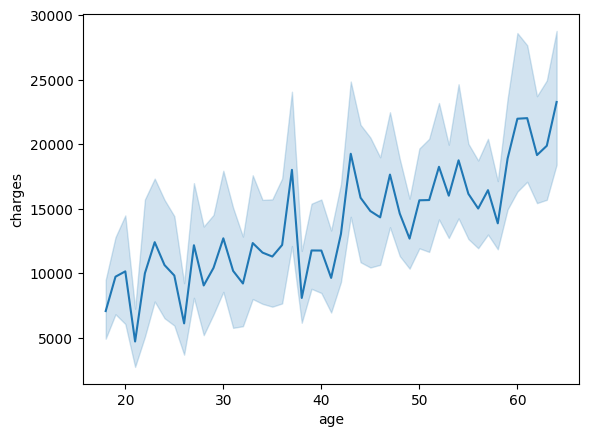

In [24]:
sns.lineplot(x='age', y='charges', data=df)

<Axes: xlabel='age', ylabel='bmi'>

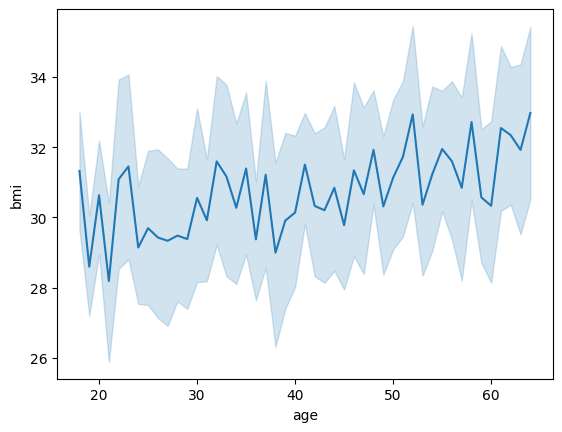

In [25]:
sns.lineplot(x='age', y='bmi', data=df)

<Axes: xlabel='smoker', ylabel='charges'>

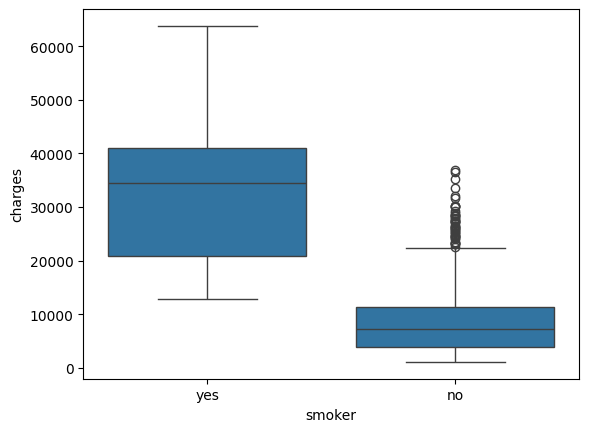

In [31]:
sns.boxplot(x='smoker', y='charges', data=df)

<Axes: xlabel='bmi', ylabel='charges'>

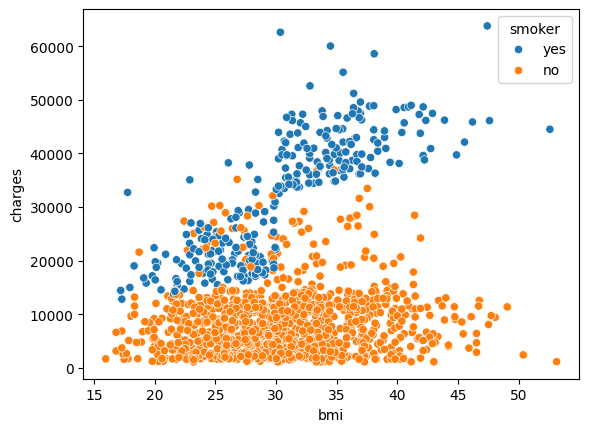

In [33]:
sns.scatterplot(x='bmi', y='charges', data=df, hue='smoker')

<Axes: xlabel='charges', ylabel='Count'>

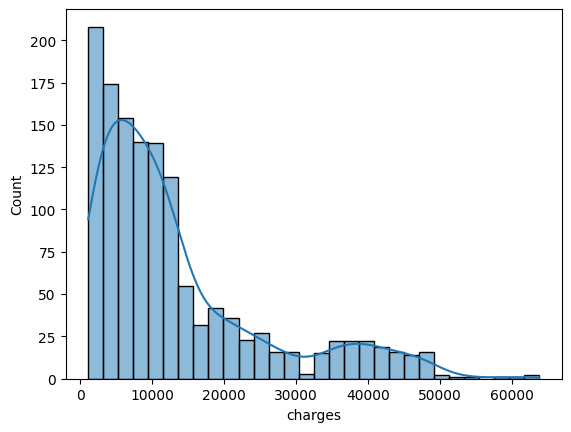

In [35]:
sns.histplot(x='charges', data=df, kde=True)

<Axes: xlabel='smoker', ylabel='count'>

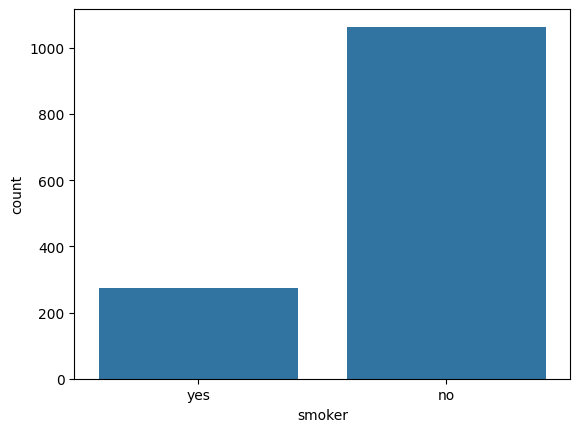

In [38]:
sns.countplot(x='smoker', data=df)

<Axes: xlabel='region', ylabel='count'>

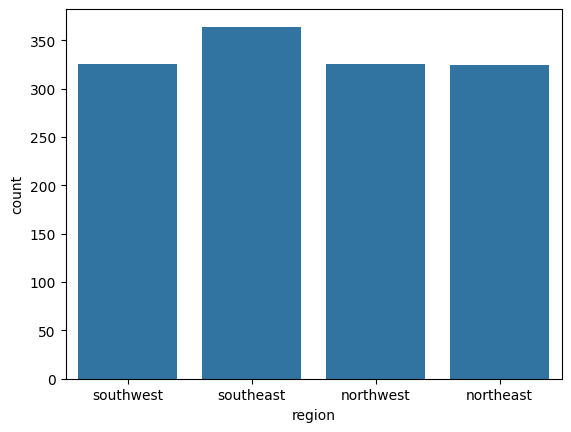

In [39]:
sns.countplot(x='region', data=df)

<Axes: xlabel='bmi', ylabel='charges'>

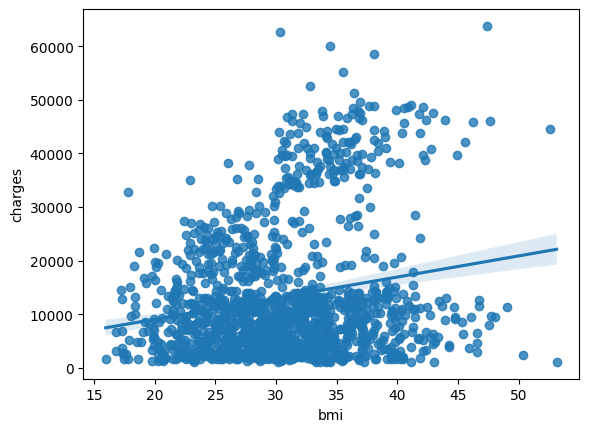

In [ ]:
sns.regplot(x='bmi', y='charges', data=df)